ผู้จัดทำ: กมพันธ์ กันธายอด 6609520116

In [20]:
# ======================================================
# Clustering Feature Combination Test
# Movie Preference Dataset
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ------------------------------------------------------
# 1 Load dataset
# ------------------------------------------------------

url = "https://raw.githubusercontent.com/kamonphankanthayod/ml-clustering-credit-card/refs/heads/main/cc_general_mini.csv"

df = pd.read_csv(url)

df

,CUST_ID,BALANCE,PURCHASES,CREDIT_LIMIT,PAYMENTS
0,C10001,40.900749,95.40,1000.0,201.802084
1,C10002,3202.467416,0.00,7000.0,4103.032597
2,C10003,2495.148862,773.17,7500.0,622.066742
3,C10004,1666.670542,1499.00,7500.0,0.000000
4,C10005,817.714335,16.00,1200.0,678.334763
...,...,...,...,...,...
8945,C19186,28.493517,291.12,1000.0,325.594462
8946,C19187,19.183215,300.00,1000.0,275.861322
8947,C19188,23.398673,144.40,1000.0,81.270775
8948,C19189,13.457564,0.00,500.0,52.549959


เช็ค Missing Values / NaN

In [23]:
print(df.isnull().sum())

print(df[df['CREDIT_LIMIT'].isnull()])

CUST_ID         0
BALANCE         0
PURCHASES       0
CREDIT_LIMIT    1
PAYMENTS        0
dtype: int64
     CUST_ID    BALANCE  PURCHASES  CREDIT_LIMIT  PAYMENTS
5203  C15349  18.400472        0.0           NaN  9.040017


พบว่ามี Missing Values / NaN อยู่ 1 แถว เราจะลบออก

In [24]:
df = df.dropna(subset=['CREDIT_LIMIT'])

print(df.isnull().sum())

CUST_ID         0
BALANCE         0
PURCHASES       0
CREDIT_LIMIT    0
PAYMENTS        0
dtype: int64


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8949 entries, 0 to 8949
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CUST_ID       8949 non-null   object 
 1   BALANCE       8949 non-null   float64
 2   PURCHASES     8949 non-null   float64
 3   CREDIT_LIMIT  8949 non-null   float64
 4   PAYMENTS      8949 non-null   float64
dtypes: float64(4), object(1)
memory usage: 419.5+ KB


จาก ผู้ใช้จำนวน 8,950 คน เหลือ ผู้ใช้จำนวน 8,949 คน

In [26]:
# ------------------------------------------------------
# 2 Define candidate features
# ------------------------------------------------------

all_features = [
    "BALANCE",
    "PURCHASES",
    "CREDIT_LIMIT",
    "PAYMENTS"
]

# ------------------------------------------------------
# 3 Generate combinations (2,3,4 features)
# ------------------------------------------------------

feature_sets = []

for r in [2,3,4]:
    comb = list(itertools.combinations(all_features, r))
    for c in comb:
        feature_sets.append(list(c))

print(len(feature_sets))
print(feature_sets)

K_range = range(2,11)

summary_results = []

11
[['BALANCE', 'PURCHASES'], ['BALANCE', 'CREDIT_LIMIT'], ['BALANCE', 'PAYMENTS'], ['PURCHASES', 'CREDIT_LIMIT'], ['PURCHASES', 'PAYMENTS'], ['CREDIT_LIMIT', 'PAYMENTS'], ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT'], ['BALANCE', 'PURCHASES', 'PAYMENTS'], ['BALANCE', 'CREDIT_LIMIT', 'PAYMENTS'], ['PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS'], ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']]


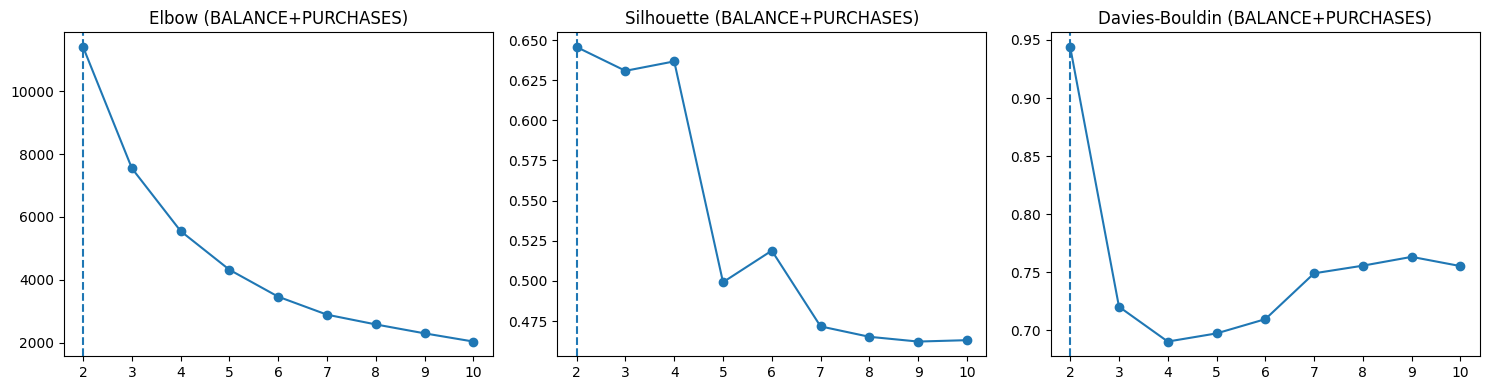

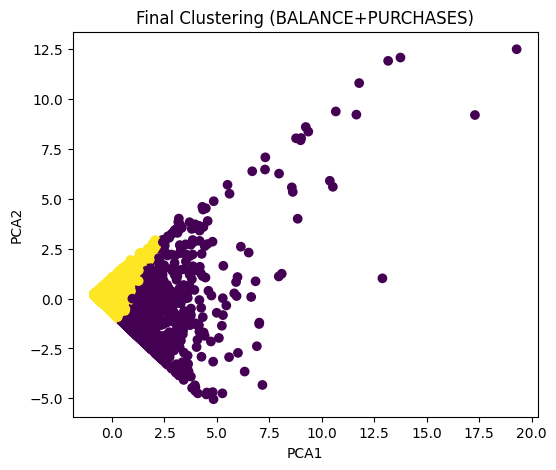

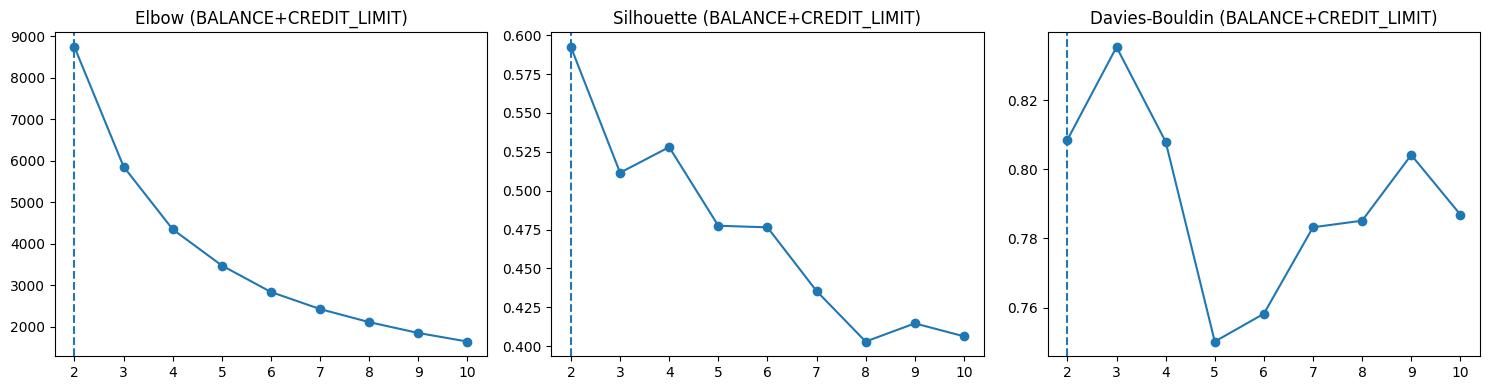

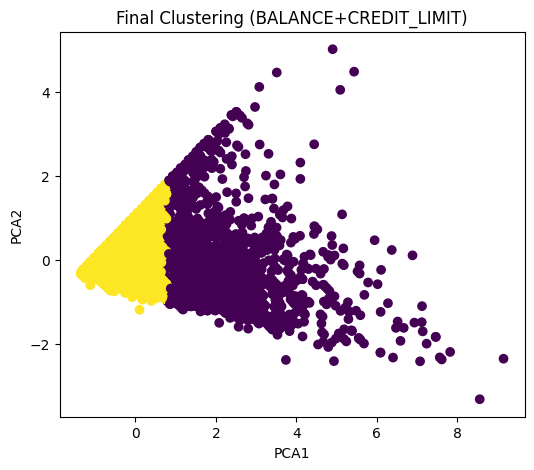

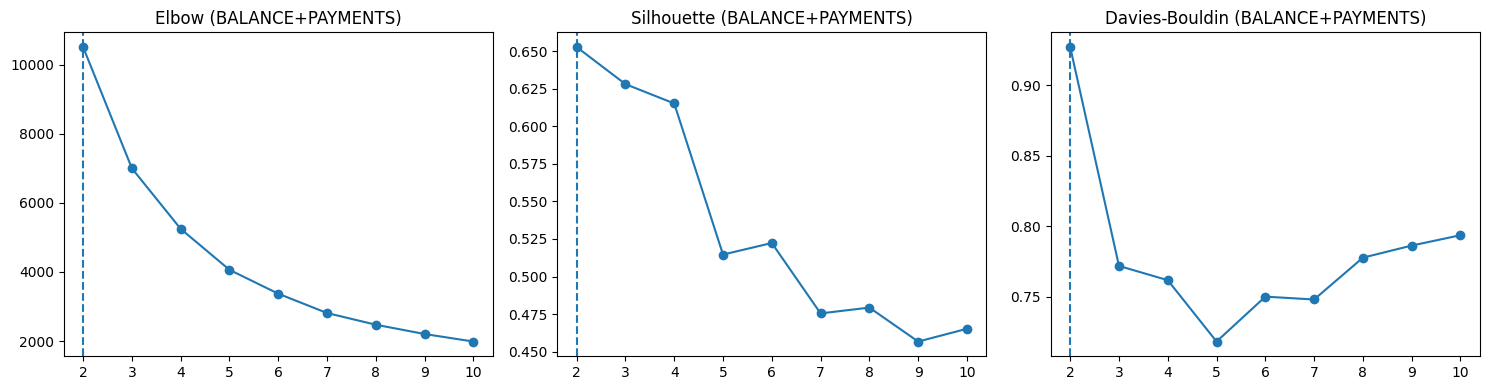

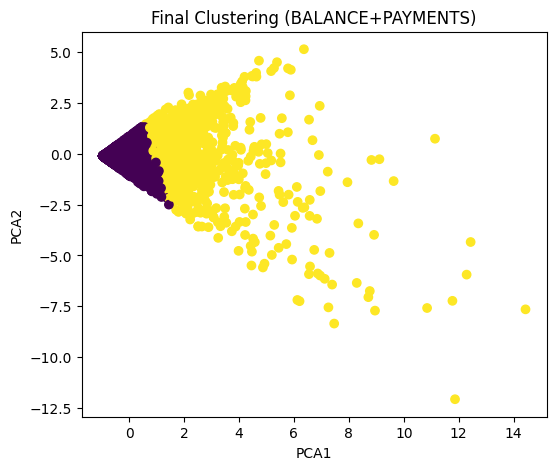

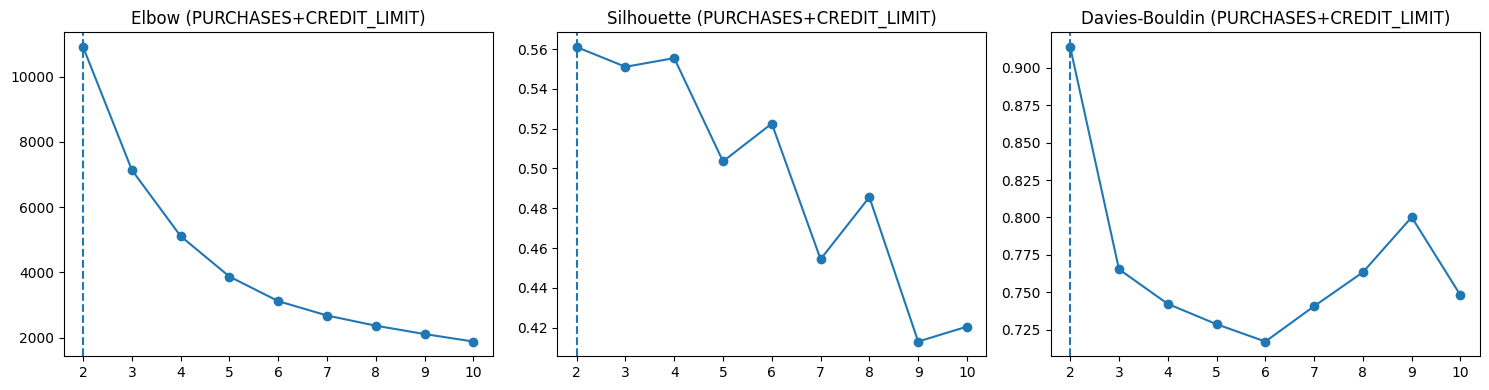

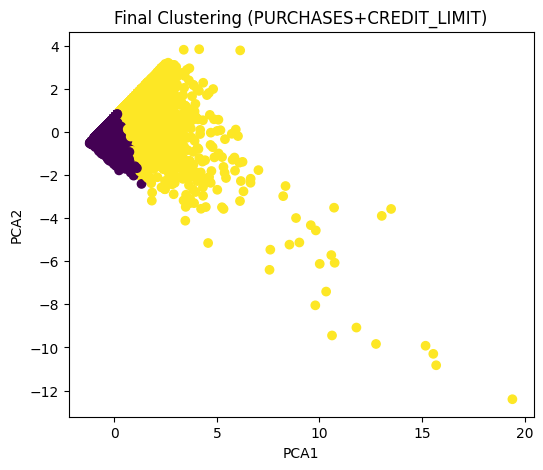

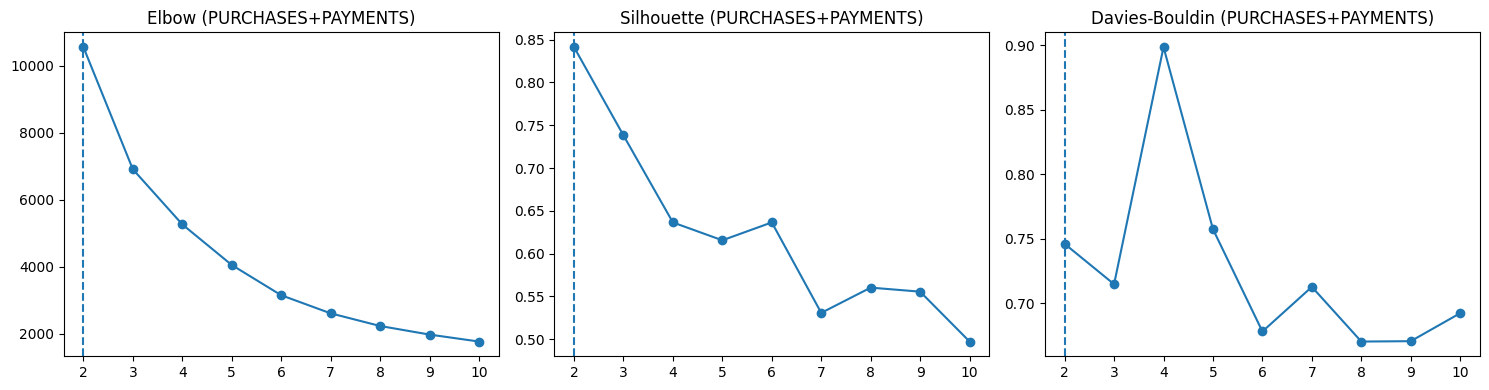

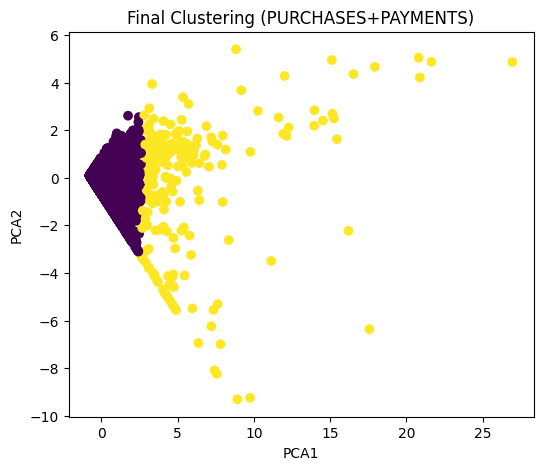

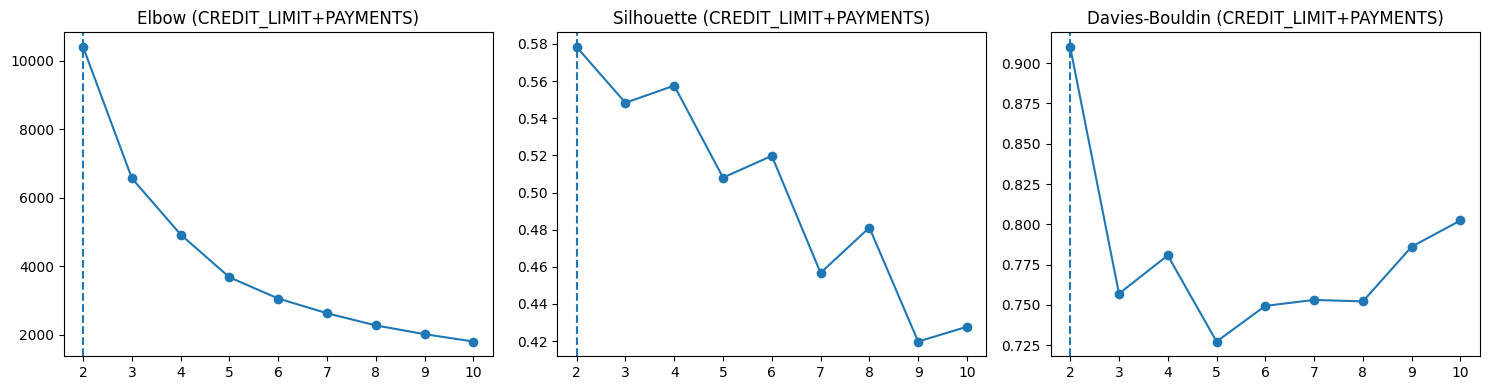

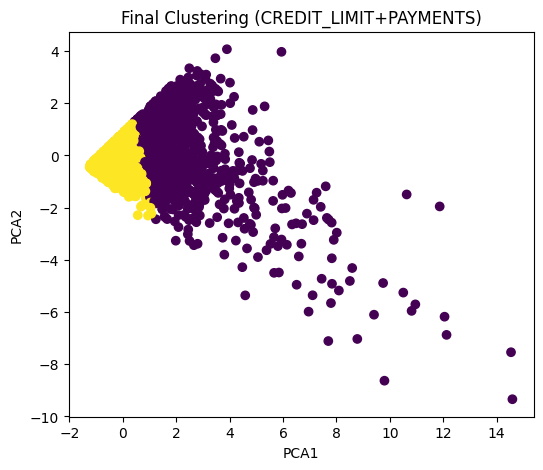

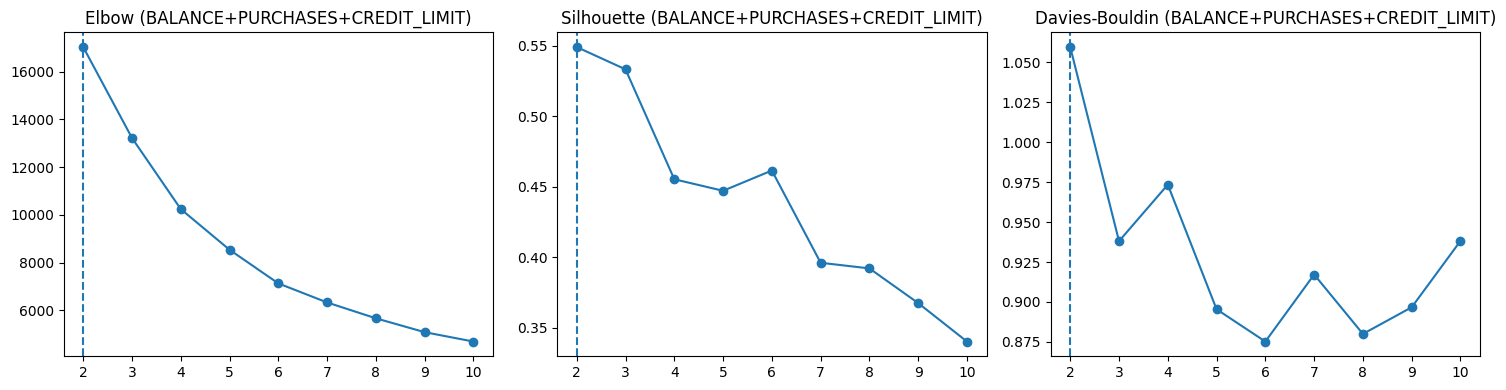

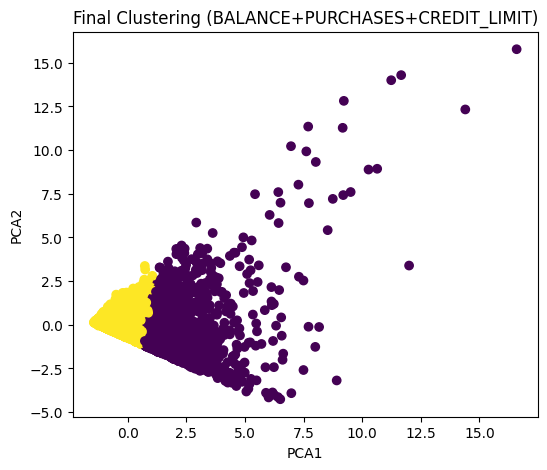

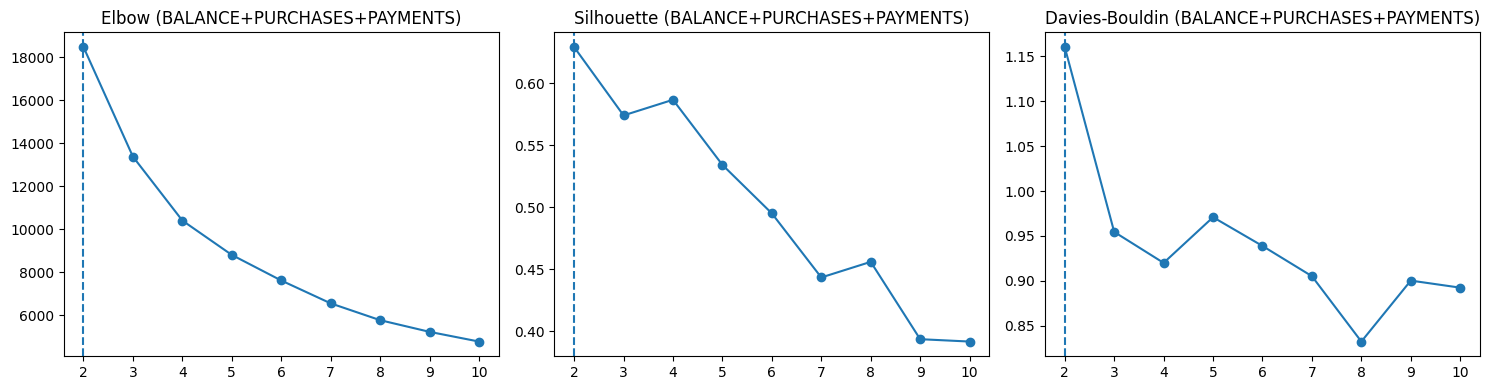

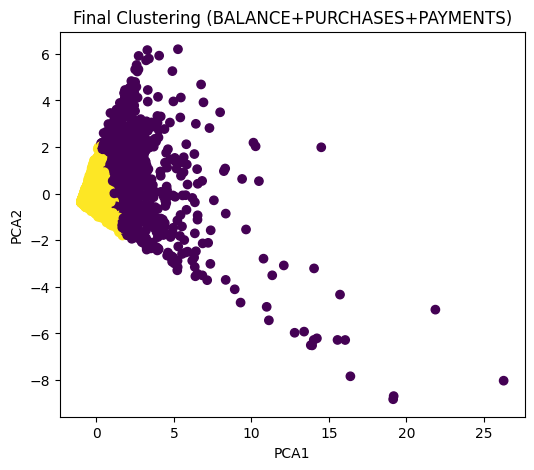

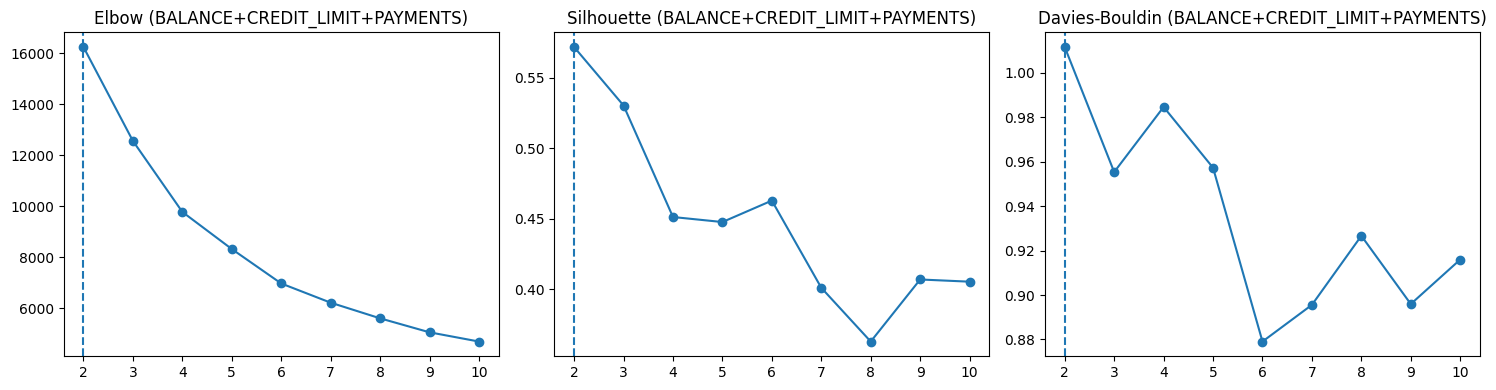

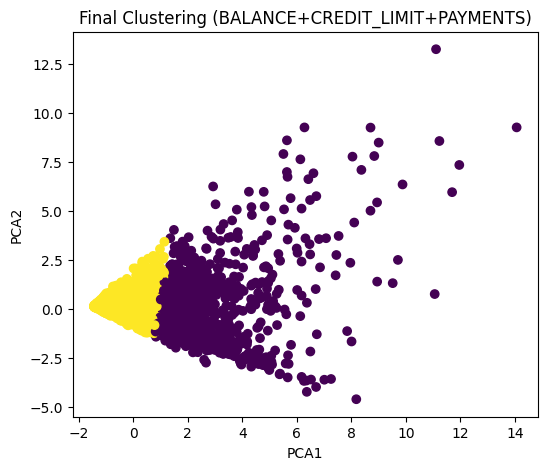

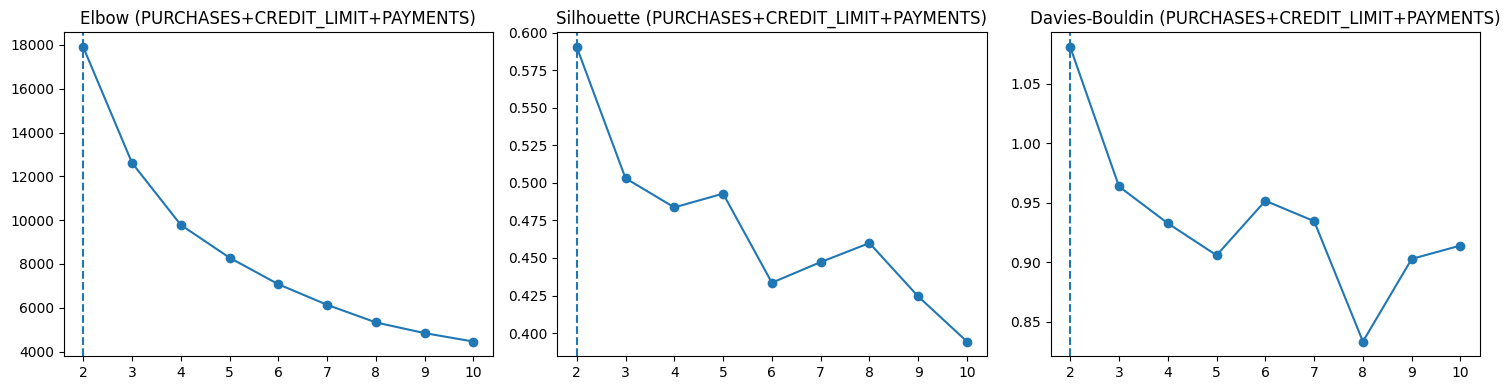

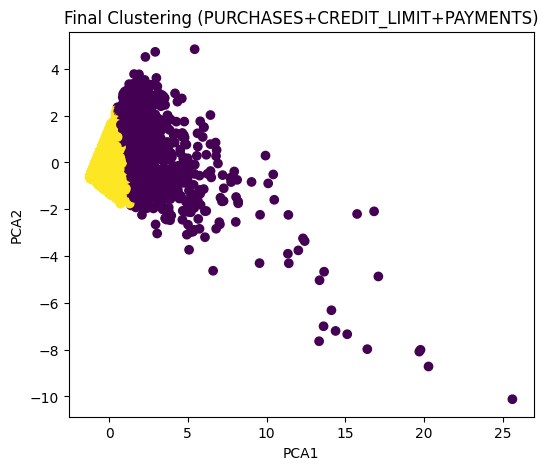

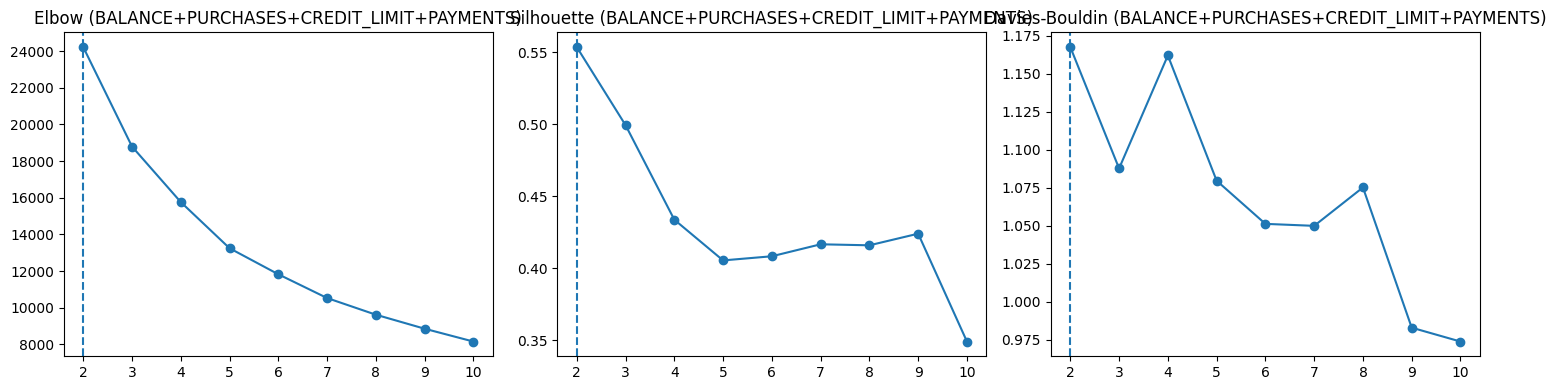

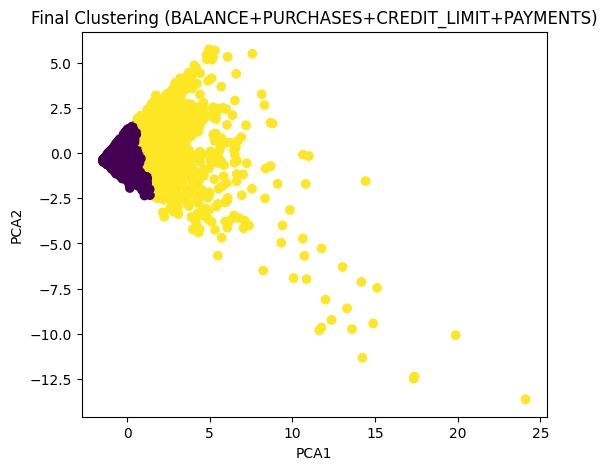

In [27]:
# ------------------------------------------------------
# 4 Evaluate clustering
# ------------------------------------------------------

for features in feature_sets:

    name = "+".join(features)

    X = df[features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    inertia = []
    silhouette = []
    dbi = []

    for k in K_range:

        model = KMeans(n_clusters=k, random_state=42, n_init=10)

        labels = model.fit_predict(X_scaled)

        inertia.append(model.inertia_)
        silhouette.append(silhouette_score(X_scaled, labels))
        dbi.append(davies_bouldin_score(X_scaled, labels))

    best_k = K_range[np.argmax(silhouette)]

    summary_results.append([
        name,
        best_k,
        max(silhouette),
        min(dbi)
    ])

    # --------------------------------------------------
    # Plot metrics
    # --------------------------------------------------

    plt.figure(figsize=(15,4))

    plt.subplot(1,3,1)
    plt.plot(K_range, inertia, marker='o')
    plt.axvline(best_k, linestyle='--')
    plt.title(f"Elbow ({name})")

    plt.subplot(1,3,2)
    plt.plot(K_range, silhouette, marker='o')
    plt.axvline(best_k, linestyle='--')
    plt.title(f"Silhouette ({name})")

    plt.subplot(1,3,3)
    plt.plot(K_range, dbi, marker='o')
    plt.axvline(best_k, linestyle='--')
    plt.title(f"Davies-Bouldin ({name})")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # Final clustering visualization
    # --------------------------------------------------

    final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)

    labels = final_model.fit_predict(X_scaled)

    pca = PCA(n_components=2)

    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(6,5))

    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)

    plt.title(f"Final Clustering ({name})")

    plt.xlabel("PCA1")
    plt.ylabel("PCA2")

    plt.show()

In [28]:
# ------------------------------------------------------
# 5 Summary ranking
# ------------------------------------------------------

summary_df = pd.DataFrame(
    summary_results,
    columns=["Features","Best_k","Best_Silhouette","Best_DBI"]
)

summary_df = summary_df.sort_values(
    by=["Best_Silhouette","Best_DBI"],
    ascending=[False,True]
)

summary_df = summary_df.reset_index(drop=True)

summary_df["Rank"] = summary_df.index + 1

summary_df = summary_df[
    ["Rank","Features","Best_k","Best_Silhouette","Best_DBI"]
]

print("\n================ Clustering Ranking =================")
print(summary_df.to_string(index=False))


================ Clustering Ranking =================
 Rank                                Features  Best_k  Best_Silhouette  Best_DBI
    1                      PURCHASES+PAYMENTS       2         0.841414  0.670389
    2                        BALANCE+PAYMENTS       2         0.652627  0.718326
    3                       BALANCE+PURCHASES       2         0.645617  0.690169
    4              BALANCE+PURCHASES+PAYMENTS       2         0.629309  0.832373
    5                    BALANCE+CREDIT_LIMIT       2         0.592348  0.750180
    6         PURCHASES+CREDIT_LIMIT+PAYMENTS       2         0.590428  0.833323
    7                   CREDIT_LIMIT+PAYMENTS       2         0.578334  0.727297
    8           BALANCE+CREDIT_LIMIT+PAYMENTS       2         0.571558  0.879063
    9                  PURCHASES+CREDIT_LIMIT       2         0.561064  0.716968
   10 BALANCE+PURCHASES+CREDIT_LIMIT+PAYMENTS       2         0.553769  0.973815
   11          BALANCE+PURCHASES+CREDIT_LIMIT       2 

2.1. ซับเซตของคุณลักษณะที่จัดกลุ่มได้ดีที่สุด คือ เซตใด

จาก Summary ranking จึงสรุปว่า เซตของคุณลักษณะ PURCHASES และ PAYMENTS        สามารถใช้เพื่อแบ่งกลุ่มได้ดีที่สุด